**Переименуйте файл в `A4_[YourLastName]_[YourFirstName].ipynb`.**  
**При сдаче приложите короткий комментарий (или видео), где вы объясняете основные выводы.**

# Assignment 4 / Лекция 4: псевдообратная матрица, обусловленность и регуляризация

В этой работе мы изучаем:
- решение МНК через псевдообратную матрицу;
- плохую обусловленность и нестабильность OLS;
- стабилизацию с помощью Ridge;
- разреженность Lasso;
- grouping effect у Elastic Net.

Мы будем работать в двух режимах:
1. **синтетический пример**, где можно увидеть все эффекты очень явно;
2. **(опционально)** real-world пример на табличных данных.


## 0. Настройка окружения

Импортируйте необходимые библиотеки.  
Минимальный набор: `numpy`, `pandas`, `matplotlib`, `sklearn`.

Удобно также импортировать:
- `PolynomialFeatures`
- `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`
- `GridSearchCV`, `train_test_split`
- `StandardScaler`, `Pipeline`
- `mean_squared_error`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn


## 1. Синтетические данные

Рассмотрим одномерную регрессию
$$
y_i=f(x_i)+\xi_i,\qquad
f(x)=x^3-5x^2+3x+1,
$$
где
$$
x_i\sim U(-1,5),\qquad \xi_i\sim \mathcal N(0,1),\qquad i=1,\dots,m,
$$
а размер выборки $m=30$.

Сначала сгенерируйте выборку и сохраните:
- вектор входов $x$,
- вектор ответов $y$,
- значения ``истинной'' функции $f(x)$ на плотной сетке.


In [9]:
def f(x):
  return x**3 - 5*x**2 +3*x + 1

m=30
X = np.random.uniform(-1, 5, size=m)
noise = np.random.normal(0, 1, size=m)
print(X.shape, noise.shape)
y = f(X) + noise

X_grid = np.linspace(-1, 5, 100)
y_grid = f(X_grid)

(30,) (30,)


### 1.1. Визуализация данных

Постройте:
1. график функции $f(x)$;
2. scatter plot точек $(x_i,y_i)$.

Кратко прокомментируйте, насколько шум велик по сравнению с масштабом сигнала.


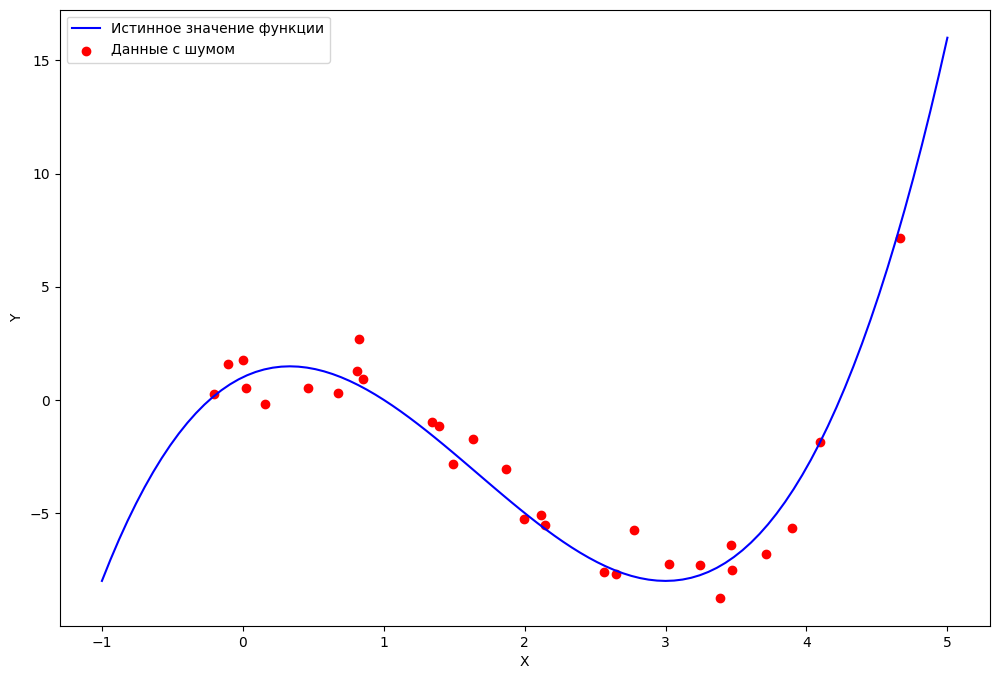

In [22]:
plt.figure(figsize=(12, 8))
plt.plot(X_grid, y_grid, label='Истинное значение функции', c='blue')
# plt.subplot(1, 2, 2)
plt.scatter(X, y, label='Данные с шумом', c='red')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

Шум можно считать умеренным или низким. Он заметен визуально (точки не лежат идеально на линии), но он не искажает общую структуру функции.

## 2. Ordinary Least Squares и псевдообратная матрица

Рассмотрим полиномиальные признаки
$$
\mathbf x=(x,x^2,\dots,x^d).
$$

Для фиксированной степени $d$ постройте дизайн-матрицу $X_d$ и решите задачу МНК.

### 2.1. Степени $d=3$ и $d=10$
Для $d=3$ и $d=10$:

1. постройте матрицы признаков;
2. найдите OLS-решение стандартным способом (`LinearRegression`);
3. найдите решение через псевдообратную матрицу:
   $$
   \widehat w = X^+ y;
   $$
4. проверьте, что предсказания совпадают (с точностью до численной ошибки).

Сделайте вывод: как связаны OLS и псевдообратная матрица в этом примере?


### 2.2. Сингулярные числа и обусловленность

Для $d=3$ и $d=10$:

1. найдите сингулярные числа матриц $X_d$;
2. постройте их на одном графике (например, в логарифмической шкале);
3. вычислите число обусловленности
$$
\kappa_2(X_d)=\frac{\sigma_{\max}(X_d)}{\sigma_{\min}(X_d)}
$$
(если матрица полного столбцового ранга),
или псевдо-число обусловленности
$$
\kappa_2^+(X_d)=\frac{\sigma_1(X_d)}{\sigma_r(X_d)},
$$
где $\sigma_r$ — наименьшее ненулевое сингулярное число.

Сравните случаи $d=3$ и $d=10$.


### 2.3. Нестабильность OLS при возмущении правой части

Зафиксируйте степень $d=10$.  
Постройте малое возмущение правой части:
$$
y^{(\varepsilon)} = y + \delta y,
$$
где $\delta y$ имеет малую норму.

1. Найдите OLS-решения для $y$ и для $y^{(\varepsilon)}$.
2. Сравните:
   - $\|\delta y\|_2$,
   - $\|\delta w\|_2$,
   - относительные изменения коэффициентов.
3. Сопоставьте результат с величиной $1/\sigma_r(X)$.

Кратко объясните, почему маленькое возмущение в $y$ может сильно менять коэффициенты.


### 2.4. Визуализация предсказаний OLS

Для $d=3$ и $d=10$:
1. постройте графики предсказаний OLS;
2. наложите их на истинную функцию $f(x)$;
3. сравните поведение моделей.

Обратите внимание: нестабильность коэффициентов и качество предсказания — не одно и то же.


## 3. Ridge regression

Напомним, что Ridge решает задачу
$$
\min_w \|y-Xw\|_2^2+\lambda\|w\|_2^2.
$$

### 3.1. Подбор параметра
Зафиксируйте большую степень, например $d=10$ или $d=15$.
С помощью `GridSearchCV` подберите лучший параметр регуляризации $\alpha$.

Нужно:
1. подобрать $\alpha$;
2. посчитать RMSE;
3. построить график предсказания;
4. сравнить коэффициенты Ridge и OLS.


### 3.2. Ridge и устойчивость

Повторите эксперимент с возмущением правой части для лучшего Ridge-решения.

Сравните:
- насколько меняются коэффициенты у OLS;
- насколько меняются коэффициенты у Ridge.

Сделайте вывод: почему Ridge стабилизирует решение?


## 4. Lasso regression

Рассмотрим задачу
$$
\min_w \|y-Xw\|_2^2+\lambda\|w\|_1.
$$

Для той же большой степени $d$:
1. подберите лучший параметр $\alpha$;
2. вычислите RMSE;
3. постройте график предсказания;
4. сравните коэффициенты Lasso и Ridge;
5. посчитайте, сколько коэффициентов Lasso занулил.


## 5. Elastic Net

Elastic Net сочетает штрафы $\ell_1$ и $\ell_2$:
$$
\min_w \|y-Xw\|_2^2+\lambda_1\|w\|_1+\lambda_2\|w\|_2^2.
$$
В `scikit-learn` обычно используется параметризация через `alpha` и `l1_ratio`.

Для той же степени $d$:
1. подберите лучшие `alpha` и `l1_ratio`;
2. вычислите RMSE;
3. постройте график предсказания;
4. сравните коэффициенты Elastic Net с Ridge и Lasso;
5. прокомментируйте, виден ли компромисс между разреженностью и устойчивостью.


## 6. Real-world пример

Используйте один из реальных датасетов:
- California housing,
- Ames housing,
- или другой табличный датасет регрессии.

Что сделать:
1. Выберите несколько числовых признаков.
2. Сравните спектр сингулярных чисел:
   - до стандартизации,
   - после стандартизации.
3. Обучите OLS и Ridge.
4. Сравните:
   - RMSE,
   - устойчивость коэффициентов,
   - число обусловленности.

Кратко прокомментируйте: есть ли признаки плохой обусловленности в реальных данных?


## 7. Что должно быть в выводах

В конце ноутбука кратко ответьте на вопросы:

1. Почему псевдообратная матрица связана с решением МНК?
2. Что показывает спектр сингулярных чисел дизайн-матрицы?
3. Почему OLS может быть неустойчив при плохой обусловленности?
4. Как Ridge меняет эту ситуацию?
5. В чём различие между Ridge, Lasso и Elastic Net на практике?


## 8. Финальный комментарий

Сформулируйте 3–5 основных выводов по работе.  
Желательно отдельно отметить:
- что происходило с коэффициентами,
- что происходило с качеством предсказания,
- где именно регуляризация оказалась полезной.
